# Phân tích độ tương đồng vector — Hệ thống gợi ý BĐS

Notebook này dùng để:
1. Kết nối tới Qdrant, lấy vector của các bài đăng (`posts`) và user (`users`)
2. Tính ma trận **cosine similarity** giữa các post với nhau
3. Vẽ **heatmap** thể hiện độ tương đồng giữa các post
4. Giảm chiều vector (PCA/t-SNE) xuống 2D để vẽ **scatter plot** vị trí user so với các post
5. Kiểm tra xem các bài được gợi ý cho user có thực sự gần với user vector không

> Yêu cầu: Qdrant đang chạy ở `localhost:6333` và đã có dữ liệu (đã chạy `test_manual.py` hoặc hệ thống thật đã index).

## 1. Cài đặt & kết nối

In [2]:
# !pip install qdrant-client pandas numpy matplotlib seaborn scikit-learn --break-system-packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from qdrant_client import QdrantClient
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# ===== CẤU HÌNH =====
QDRANT_HOST = "localhost"
QDRANT_PORT = 6333
POST_COLLECTION = "posts"
USER_COLLECTION = "users"

client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)
print("✅ Connected to Qdrant")
print("Collections:", [c.name for c in client.get_collections().collections])

✅ Connected to Qdrant
Collections: ['posts', 'users']


## 2. Lấy toàn bộ vector bài đăng từ Qdrant

In [3]:
def fetch_all_points(collection_name, with_vectors=True):
    """Lấy toàn bộ points trong 1 collection (dùng scroll để lấy hết)"""
    points = []
    next_page = None
    while True:
        result, next_page = client.scroll(
            collection_name=collection_name,
            limit=100,
            offset=next_page,
            with_vectors=with_vectors,
            with_payload=True
        )
        points.extend(result)
        if next_page is None:
            break
    return points

post_points = fetch_all_points(POST_COLLECTION)
print(f"Tổng số bài đăng trong Qdrant: {len(post_points)}")

# Build DataFrame
post_data = []
for p in post_points:
    payload = p.payload or {}
    post_data.append({
        "id": p.id,
        "title": payload.get("title", f"Post {p.id}"),
        "propertyType": payload.get("propertyType", ""),
        "listingType": payload.get("listingType", ""),
        "wardName": payload.get("wardName", ""),
        "vector": p.vector
    })

df_posts = pd.DataFrame(post_data)
df_posts.head(10)

Tổng số bài đăng trong Qdrant: 10


,id,title,propertyType,listingType,wardName,vector
0,1,Post 1,LAND,SALE,xã Bà Nà,"[0.15715018, 0.0106895305, -0.014628021, 0.032..."
1,2,Post 2,HOUSE,SALE,phường Ngũ Hành Sơn,"[0.13391632, 0.032229856, 0.043027747, 0.02651..."
2,4,Post 4,APARTMENT,RENT,phường Hải Châu,"[0.06293832, 0.036738843, -0.013545778, 0.0071..."
3,5,Post 5,HOUSE,RENT,phường Ngũ Hành Sơn,"[0.12599117, 0.068803556, -0.022816204, 0.0405..."
4,7,Post 7,HOUSE,SALE,phường Hải Châu,"[0.15441042, 0.013829034, 0.014024836, 0.01386..."
5,8,Post 8,HOUSE,SALE,phường Cẩm Lệ,"[0.14856943, -0.029336486, 0.016281353, -0.032..."
6,9,Post 9,HOUSE,SALE,phường Hòa Cường,"[0.13729037, 0.03792376, -0.005655337, 0.02227..."
7,10,Post 10,HOUSE,SALE,phường Hòa Khánh,"[0.06083693, 0.08238786, 0.07188579, 0.0440103..."
8,11,Post 11,HOUSE,SALE,phường Hải Vân,"[0.09371641, 0.03550309, 0.0010960888, 0.00850..."
9,12,Post 12,HOUSE,SALE,phường Hải Châu,"[0.17186037, 0.009277472, 0.059474513, 0.02809..."


## 3. Ma trận Cosine Similarity giữa các Post

In [4]:
# Stack tất cả vector thành matrix (N x 384)
post_vectors = np.array(df_posts["vector"].tolist())
post_labels = [f"#{row.id} {row.title[:25]}" for _, row in df_posts.iterrows()]

# Tính cosine similarity giữa từng cặp post
sim_matrix = cosine_similarity(post_vectors)

df_sim = pd.DataFrame(sim_matrix, index=post_labels, columns=post_labels)
df_sim.round(2)

,#1 Post 1,#2 Post 2,#4 Post 4,#5 Post 5,#7 Post 7,#8 Post 8,#9 Post 9,#10 Post 10,#11 Post 11,#12 Post 12
#1 Post 1,1.00,0.62,0.51,0.48,0.62,0.67,0.57,0.30,0.66,0.47
#2 Post 2,0.62,1.00,0.63,0.65,0.71,0.65,0.67,0.61,0.70,0.57
#4 Post 4,0.51,0.63,1.00,0.66,0.59,0.45,0.65,0.47,0.69,0.59
#5 Post 5,0.48,0.65,0.66,1.00,0.72,0.48,0.62,0.70,0.62,0.67
#7 Post 7,0.62,0.71,0.59,0.72,1.00,0.68,0.70,0.54,0.73,0.58
#8 Post 8,0.67,0.65,0.45,0.48,0.68,1.00,0.60,0.28,0.56,0.42
#9 Post 9,0.57,0.67,0.65,0.62,0.70,0.60,1.00,0.45,0.54,0.55
#10 Post 10,0.30,0.61,0.47,0.70,0.54,0.28,0.45,1.00,0.48,0.56
#11 Post 11,0.66,0.70,0.69,0.62,0.73,0.56,0.54,0.48,1.00,0.53
#12 Post 12,0.47,0.57,0.59,0.67,0.58,0.42,0.55,0.56,0.53,1.00


## 4. Heatmap độ tương đồng giữa các Post

Màu càng sáng (gần 1.0) → 2 bài đăng càng giống nhau về nội dung/đặc điểm.
Đường chéo luôn = 1.0 (1 bài so với chính nó).

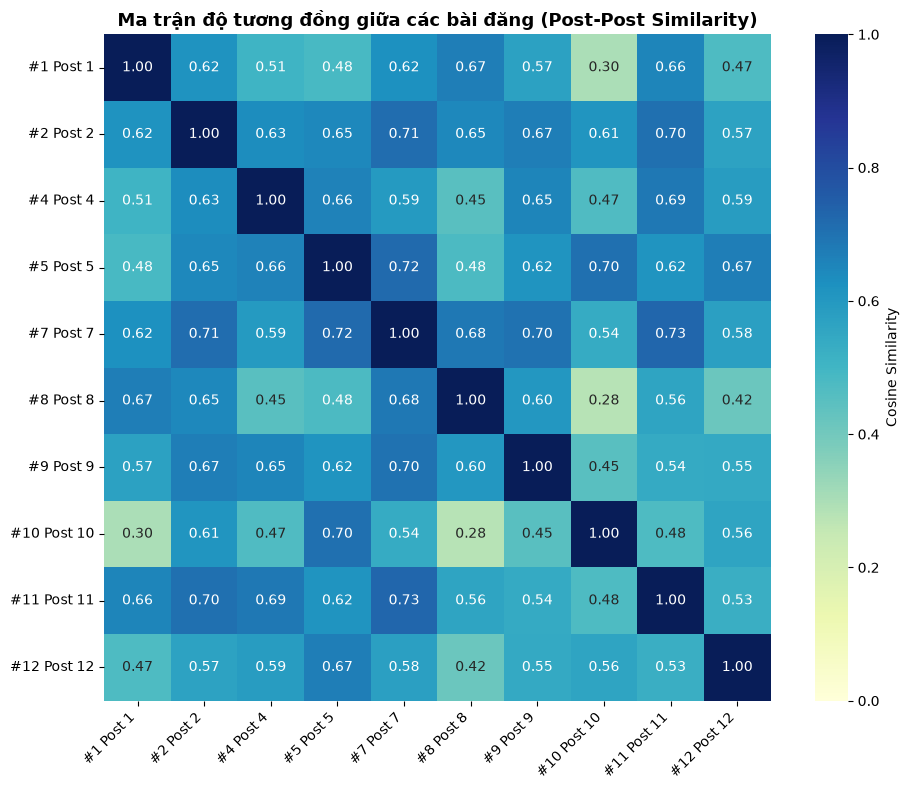

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_sim,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    square=True,
    cbar_kws={"label": "Cosine Similarity"}
)
plt.title("Ma trận độ tương đồng giữa các bài đăng (Post-Post Similarity)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("post_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Kiểm tra gợi ý "Tương tự" cho 1 bài cụ thể

Chọn 1 `post_id`, lấy top-K bài có độ tương đồng cao nhất (loại trừ chính nó) —
đây chính là logic của API `/recommend/similar`.

In [6]:
TARGET_POST_ID = df_posts["id"].iloc[0]  # đổi thành id bạn muốn kiểm tra
TOP_K = 5

target_idx = df_posts.index[df_posts["id"] == TARGET_POST_ID][0]
sims = sim_matrix[target_idx]

# Sắp xếp giảm dần, loại trừ chính nó
order = np.argsort(sims)[::-1]
order = [i for i in order if df_posts.iloc[i]["id"] != TARGET_POST_ID][:TOP_K]

print(f"🎯 Bài đang xem: #{TARGET_POST_ID} - {df_posts.iloc[target_idx]['title']}\n")
print(f"Top {TOP_K} bài tương tự:")
for rank, idx in enumerate(order, 1):
    row = df_posts.iloc[idx]
    print(f"  {rank}. #{row['id']} {row['title']}  (similarity = {sims[idx]:.3f})")

🎯 Bài đang xem: #1 - Post 1

Top 5 bài tương tự:
  1. #8 Post 8  (similarity = 0.669)
  2. #11 Post 11  (similarity = 0.655)
  3. #7 Post 7  (similarity = 0.622)
  4. #2 Post 2  (similarity = 0.621)
  5. #9 Post 9  (similarity = 0.572)


## 6. Lấy User Vector và tính similarity với từng Post

Đây chính là logic của API `/recommend/personal` — user vector được so sánh
với toàn bộ post vector để tìm bài phù hợp với sở thích.

In [7]:
user_points = fetch_all_points(USER_COLLECTION)
print(f"Tổng số user có vector trong Qdrant: {len(user_points)}")

user_data = []
for u in user_points:
    user_data.append({
        "userId": u.id,
        "vector": u.vector
    })

df_users = pd.DataFrame(user_data)
df_users

Tổng số user có vector trong Qdrant: 2


,userId,vector
0,2,"[0.16268949, 0.015999323, -0.0033037143, 0.033..."
1,3,"[0.15009806, 0.047729325, -0.01169341, 0.02564..."


In [8]:
if len(df_users) == 0:
    print("⚠️ Chưa có user vector nào trong Qdrant. Hãy thực hiện tương tác (VIEW/SAVE/CONTACT) trước.")
else:
    TARGET_USER_ID = df_users["userId"].iloc[0]  # đổi thành userId muốn kiểm tra

    user_vector = np.array(df_users[df_users["userId"] == TARGET_USER_ID]["vector"].iloc[0]).reshape(1, -1)

    # Similarity giữa user vector và từng post vector
    user_post_sims = cosine_similarity(user_vector, post_vectors)[0]

    df_user_post = pd.DataFrame({
        "postId": df_posts["id"],
        "title": df_posts["title"],
        "propertyType": df_posts["propertyType"],
        "similarity": user_post_sims
    }).sort_values("similarity", ascending=False)

    print(f"🎯 User #{TARGET_USER_ID} — độ phù hợp với từng bài đăng (sắp xếp giảm dần):\n")
    df_user_post

🎯 User #2 — độ phù hợp với từng bài đăng (sắp xếp giảm dần):



## 7. Bar chart — Top bài đăng phù hợp nhất với User

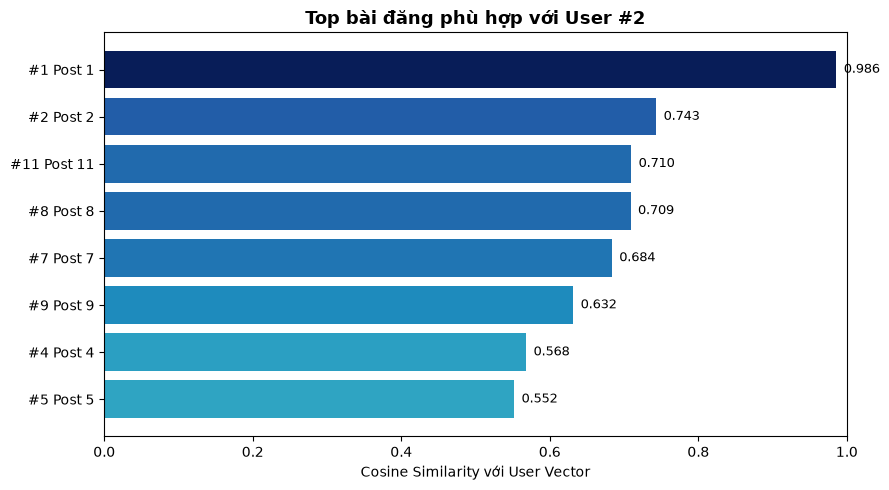

In [9]:
if len(df_users) > 0:
    top_n = df_user_post.head(8)

    plt.figure(figsize=(9, 5))
    colors = plt.cm.YlGnBu(top_n["similarity"] / top_n["similarity"].max())
    bars = plt.barh(
        [f"#{r.postId} {r.title[:30]}" for _, r in top_n.iterrows()],
        top_n["similarity"],
        color=colors
    )
    plt.xlabel("Cosine Similarity với User Vector")
    plt.title(f"Top bài đăng phù hợp với User #{TARGET_USER_ID}", fontsize=13, fontweight="bold")
    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    for bar, val in zip(bars, top_n["similarity"]):
        plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("user_post_similarity_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Scatter plot 2D — Vị trí User Vector so với các Post Vector

Dùng PCA giảm chiều từ 384D xuống 2D để minh họa trực quan trên báo cáo.
Vector nào càng gần User → khả năng được gợi ý càng cao.

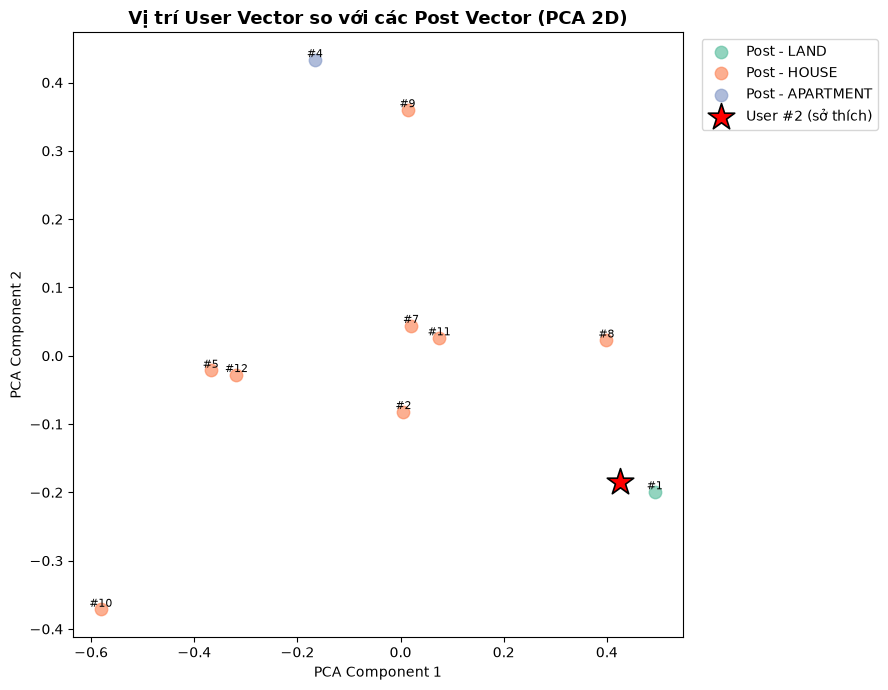

Tổng phương sai giải thích bởi 2 thành phần PCA: 42.7%


In [10]:
if len(df_users) > 0:
    # Gộp post vectors + user vector để PCA cùng 1 không gian
    all_vectors = np.vstack([post_vectors, user_vector])

    pca = PCA(n_components=2, random_state=42)
    coords_2d = pca.fit_transform(all_vectors)

    post_coords = coords_2d[:-1]
    user_coord = coords_2d[-1]

    plt.figure(figsize=(9, 7))

    # Vẽ từng post, màu theo propertyType
    property_types = df_posts["propertyType"].unique()
    palette = sns.color_palette("Set2", len(property_types))
    color_map = dict(zip(property_types, palette))

    for ptype in property_types:
        mask = df_posts["propertyType"] == ptype
        plt.scatter(
            post_coords[mask.values, 0], post_coords[mask.values, 1],
            label=f"Post - {ptype}", s=80, alpha=0.7,
            color=color_map[ptype]
        )

    # Ghi label cho từng post point
    for i, row in df_posts.iterrows():
        plt.annotate(f"#{row['id']}", (post_coords[i, 0], post_coords[i, 1]),
                      fontsize=8, ha="center", va="bottom")

    # Vẽ user vector (to, màu đỏ, hình sao)
    plt.scatter(
        user_coord[0], user_coord[1],
        color="red", marker="*", s=400,
        label=f"User #{TARGET_USER_ID} (sở thích)",
        edgecolors="black", linewidths=1.2, zorder=5
    )

    plt.title("Vị trí User Vector so với các Post Vector (PCA 2D)", fontsize=13, fontweight="bold")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("user_post_pca_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Tổng phương sai giải thích bởi 2 thành phần PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 9. Kết luận / Nhận xét cho báo cáo

- **Heatmap (mục 4)**: thể hiện các bài đăng có cùng `propertyType`/khu vực thường
  có độ tương đồng cosine cao hơn (màu sáng hơn), chứng minh model encoder
  (`sentence-transformers`) bắt được ngữ nghĩa nội dung.
- **Top similar (mục 5)**: đối chiếu với kết quả thực tế trả về từ API
  `/recommend/similar/{postId}` để verify logic Qdrant search đúng.
- **User-Post similarity (mục 6-7)**: đối chiếu với API `/recommend/personal`
  — các bài có similarity cao nhất với user vector phải khớp với `postIds`
  trả về từ FastAPI.
- **PCA scatter (mục 8)**: minh họa trực quan cho báo cáo — user vector nằm
  gần cụm post nào thì các bài trong cụm đó sẽ được ưu tiên gợi ý.